<a href="https://colab.research.google.com/github/ElofssonLab/kb8029-book/blob/main/notebooks/session02-working-in-python.ipynb" style="display:inline-block;padding:10px 18px;background-color:#F9AB00;color:#000000;font-weight:bold;text-decoration:none;border-radius:6px;font-family:sans-serif;font-size:14px;">&#9654;&nbsp; Open in Google Colab</a>

# Session 2 — Working like a computational biologist in Python {.unnumbered}

This notebook follows the Session 2 page section by section. Four ideas run
through it: **represent** data with the right object, **explore** it
before trusting any number, **use existing tools**, and **get unstuck**
when code does not work. It uses one real dataset (mouse liver RNA-seq,
Becares et al. 2019) and one real gene family (the human globins).

Run it on the course server or in Colab (see the Setup page). Sections 6
and 8 fetch records from NCBI, so they need an internet connection.

In [1]:
# Install the libraries Colab does not come with (does nothing if they are already installed)
import importlib.util, subprocess, sys
for module, package in [("Bio", "biopython")]:
    if importlib.util.find_spec(module) is None:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", package], check=True)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import torch
import os
FIGS = "../figs" if os.path.isdir("../figs") else "."
print("pandas", pd.__version__, "| torch", torch.__version__)

pandas 3.0.0 | torch 2.5.1


## 1. Scientific Python objects

The same three transcript lengths in a list, a NumPy array and a pandas
DataFrame. Each object gives the operations that make sense for its kind
of data.

In [3]:
lengths = [628, 577, 576]                  # HBB, HBA1, HBA2 mRNA lengths (nt)
print("list * 2:        ", lengths * 2, " <- repeats the list")

arr = np.array(lengths)
print("array * 2:       ", arr * 2, " mean:", round(arr.mean(), 2), " shape:", arr.shape)
print("boolean mask:    ", arr > 600, "->", arr[arr > 600])

genes = pd.DataFrame({"gene": ["HBB", "HBA1", "HBA2"], "length": lengths})
print("\nDataFrame, rows with length > 600:")
print(genes[genes["length"] > 600])
print("\ncolumn types:\n", genes.dtypes)

list * 2:         [628, 577, 576, 628, 577, 576]  <- repeats the list
array * 2:        [1256 1154 1152]  mean: 593.67  shape: (3,)
boolean mask:     [ True False False] -> [628]

DataFrame, rows with length > 600:
  gene  length
0  HBB     628

column types:
 gene        str
length    int64
dtype: object


### Looking ahead: tensors and autograd

A PyTorch tensor is an array that can live on a GPU and remember how it
was computed. `.backward()` applies the chain rule automatically: here
it reproduces Session 1's gradient practice problem and a tensor version of
the dot product.

In [4]:
x0 = torch.tensor(1., requires_grad=True)
x1 = torch.tensor(2., requires_grad=True)
f = 3 * x0**2 + 2 * x0 * x1
f.backward()
print("gradient of 3*x0^2 + 2*x0*x1 at (1, 2):", (x0.grad.item(), x1.grad.item()), " (Session 1: (10, 2))")

a = torch.tensor([2., -1., 3.]); b = torch.tensor([1., 4., 0.])
print("dot product (2,-1,3).(1,4,0):", torch.dot(a, b).item(), " (Session 1: -2)")

# a tensor is shaped like an array: 4 DNA sequences x 8 positions, bases coded 0-3
seqs = torch.tensor([[0,1,2,3,0,1,2,3], [3,3,2,2,1,1,0,0], [1,0,1,0,2,2,3,3], [2,2,1,1,0,0,3,3]])
print("tensor shape:", tuple(seqs.shape), " first two sequences, first four bases:\n", seqs[:2, :4])

gradient of 3*x0^2 + 2*x0*x1 at (1, 2): (10.0, 2.0)  (Session 1: (10, 2))
dot product (2,-1,3).(1,4,0): -2.0  (Session 1: -2)
tensor shape: (4, 8)  first two sequences, first four bases:
 tensor([[0, 1, 2, 3],
        [3, 3, 2, 2]])


## 2. Exploring a biological dataset

Mouse liver RNA-seq, LXRα-S196A mutant against wild-type mice, both on a
high-fat/high-cholesterol diet (Becares et al. 2019), analysed with DESeq2 and shared as example data by
VolcaNoseR. First look at the table, before computing anything.

In [5]:
url = "https://raw.githubusercontent.com/JoachimGoedhart/VolcaNoseR/master/Becares-diffgenes_HFHC.csv"
df = pd.read_csv(url)
print("shape:", df.shape)
print("columns:", list(df.columns))
df.head()

shape: (3001, 9)
columns: ['Gene', 'baseMean', 'log2_FoldChange', 'FC', 'lfcSE', 'stat', 'pvalue', 'padj', 'minus_log10_pvalue']


,Gene,baseMean,log2_FoldChange,FC,lfcSE,stat,pvalue,padj,minus_log10_pvalue
0,A1bg,39.181235,1.251613,2.381075,0.298637,4.191087,0.000028,0.001705,4.555955
1,A1cf,1183.059641,0.744592,1.675500,0.191677,3.884628,0.000102,0.004557,3.989331
2,Aadac,3195.974860,0.687958,1.611002,0.156578,4.393708,0.000011,0.000817,4.954677
3,Aadat,1481.451788,0.603443,1.519338,0.181387,3.326831,0.000878,0.023207,3.056310
4,Aaed1,432.155737,0.421805,1.339603,0.192979,2.185759,0.028833,0.234806,1.540107


In [6]:
df[["baseMean", "log2_FoldChange", "pvalue", "padj"]].describe().round(3)

,baseMean,log2_FoldChange,pvalue,padj
count,3001.000,3001.000,3001.000,3001.000
mean,2217.760,-0.071,0.039,0.226
std,19582.573,0.583,0.037,0.165
min,10.126,-2.165,0.000,0.000
25%,98.839,-0.529,0.004,0.063
50%,328.715,-0.267,0.027,0.224
75%,1115.481,0.410,0.069,0.382
max,954963.992,2.387,0.120,0.499


**Look at the maxima.** The largest p-value is 0.12 and the largest
adjusted p-value 0.50. Genome-wide p-values range up to 1, so this file
is a pre-filtered list of genes with $p < 0.12$, not all genes.

In [7]:
print("largest p-value in the file:", round(df["pvalue"].max(), 3))

significant = df[df["padj"] < 0.05]
strong = df[(df["padj"] < 0.05) & (df["log2_FoldChange"].abs() > 1)]
print(f"padj < 0.05: {len(significant)} genes")
print(f"padj < 0.05 and |log2 FC| > 1: {len(strong)} genes "
      f"({(strong['log2_FoldChange'] > 0).sum()} up, {(strong['log2_FoldChange'] < 0).sum()} down)")

print("\nmost significant genes:")
print(df.sort_values("padj").head(5)[["Gene", "log2_FoldChange", "padj"]].to_string(index=False))
top_up = significant.sort_values("log2_FoldChange", ascending=False).iloc[0]
print(f"\nlargest increase among significant genes: {top_up['Gene']} "
      f"(log2 FC {top_up['log2_FoldChange']:.2f} = {2 ** top_up['log2_FoldChange']:.1f}-fold)")

print(f"\nmean expression: min {df['baseMean'].min():.0f}, median {df['baseMean'].median():.0f}, "
      f"max {df['baseMean'].max():.0f} ({df.loc[df['baseMean'].idxmax(), 'Gene']})")

largest p-value in the file: 0.12
padj < 0.05: 656 genes
padj < 0.05 and |log2 FC| > 1: 171 genes (46 up, 125 down)

most significant genes:
   Gene  log2_FoldChange         padj
 Osbpl3        -1.634422 8.070000e-18
   Spp1        -1.927235 9.060000e-15
 Syngr1        -2.164693 1.810000e-14
 Cyp2b9         1.648193 1.810000e-14
Cyp2c69         2.387006 1.810000e-14

largest increase among significant genes: Cyp2c69 (log2 FC 2.39 = 5.2-fold)

mean expression: min 10, median 329, max 954964 (Alb)


## 3. Seeing the data

Three questions, three plots: the distribution of fold changes
(histogram), fold change against expression (scatter, log axis), and
effect size against significance (volcano plot, with seaborn colouring
by a column). This cell draws the page's figure.

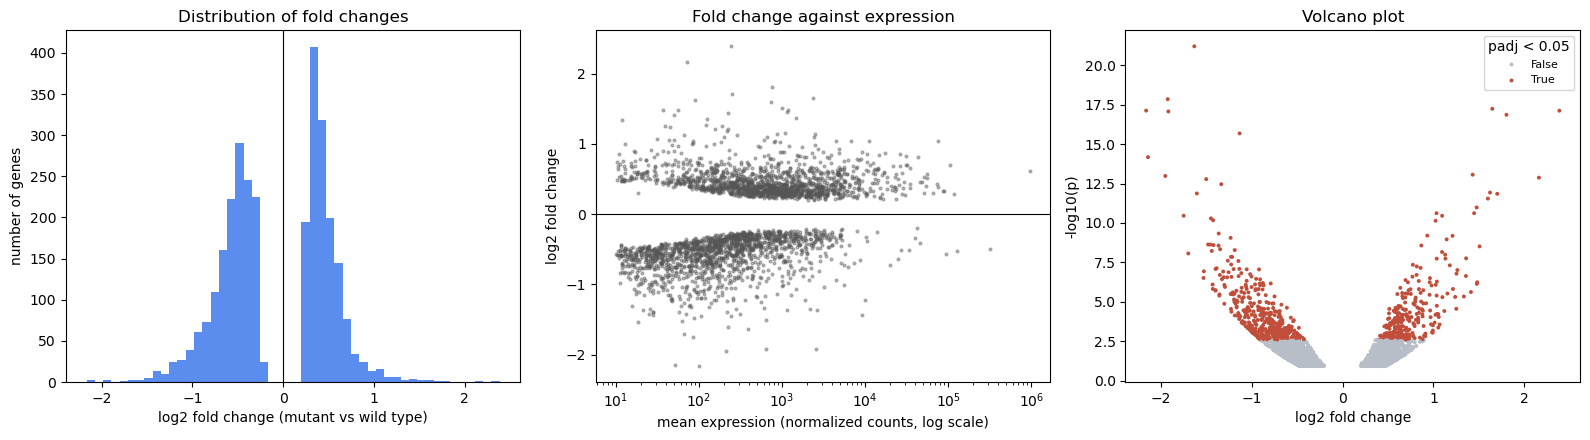

In [8]:
df["significant"] = df["padj"] < 0.05
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].hist(df["log2_FoldChange"], bins=50, color="#5b8def")
axes[0].axvline(0, color="k", lw=0.8)
axes[0].set_xlabel("log2 fold change (mutant vs wild type)"); axes[0].set_ylabel("number of genes")
axes[0].set_title("Distribution of fold changes")

axes[1].scatter(df["baseMean"], df["log2_FoldChange"], s=4, alpha=0.4, color="#555")
axes[1].set_xscale("log"); axes[1].axhline(0, color="k", lw=0.8)
axes[1].set_xlabel("mean expression (normalized counts, log scale)"); axes[1].set_ylabel("log2 fold change")
axes[1].set_title("Fold change against expression")

sns.scatterplot(data=df, x="log2_FoldChange", y="minus_log10_pvalue", hue="significant",
                palette={True: "#c14e3a", False: "#b8bec8"}, s=8, linewidth=0, ax=axes[2])
axes[2].set_xlabel("log2 fold change"); axes[2].set_ylabel("-log10(p)")
axes[2].set_title("Volcano plot"); axes[2].legend(title="padj < 0.05", fontsize=8)
plt.tight_layout(); plt.savefig(f"{FIGS}/session02-explore.png", dpi=150, bbox_inches="tight"); plt.show()

**Notice the empty band around zero** in the left and middle panels: the
pre-filtering again. Genes whose expression barely changed rarely reach
$p < 0.12$, so they are not in the file.

For comparison: the middle panel on a linear axis. Almost every gene is
squeezed against the left edge by a few extremely highly expressed ones.

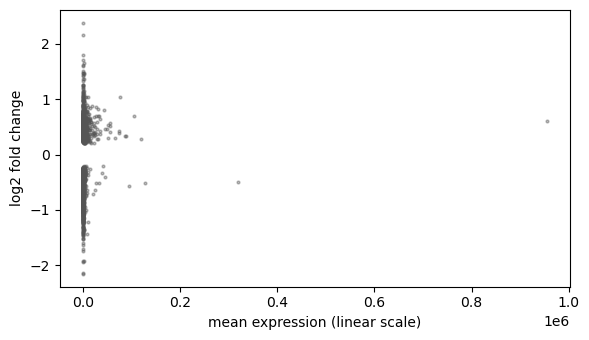

In [9]:
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.scatter(df["baseMean"], df["log2_FoldChange"], s=4, alpha=0.4, color="#555")
ax.set_xlabel("mean expression (linear scale)"); ax.set_ylabel("log2 fold change")
plt.tight_layout(); plt.show()

## 4. Asking quantitative questions

Plot first, test second. The raw-scale Pearson correlation misses the
relationship the log-scale plot shows; a test that fits the plot finds
it.

In [10]:
abs_fc = df["log2_FoldChange"].abs()
r, p = stats.pearsonr(df["baseMean"], abs_fc)
print(f"Pearson, raw expression:     r = {r:.2f}, p = {p:.2f}   <- 'no relationship'?")
r, p = stats.pearsonr(np.log10(df["baseMean"]), abs_fc)
print(f"Pearson, log10 expression:   r = {r:.2f}, p = {p:.0e}")
rho, p = stats.spearmanr(df["baseMean"], abs_fc)
print(f"Spearman (ranks):            rho = {rho:.2f}, p = {p:.0e}")

Pearson, raw expression:     r = -0.01, p = 0.43   <- 'no relationship'?
Pearson, log10 expression:   r = -0.30, p = 2e-64
Spearman (ranks):            rho = -0.42, p = 2e-129


### Existing tools for standard questions

Session 1's Welch t-test, the hierarchical clustering behind Session 4's guide
tree, and a scikit-learn model: each is one function call.

Welch t-test: t = -11.9, p = 0.0001


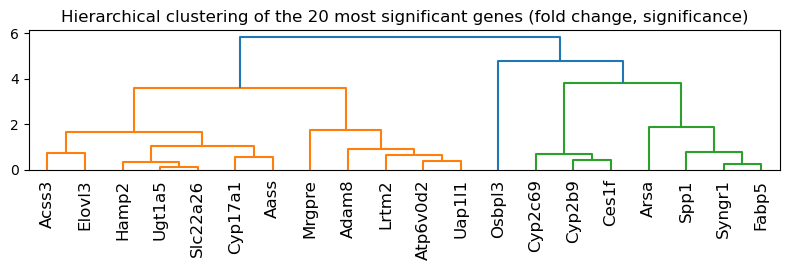

scikit-learn: |log2 FC| = 0.78 - 0.10 * log10(expression)


In [11]:
control = [5.1, 4.9, 5.3, 5.0]
treatment = [7.2, 6.8, 7.5, 7.0]
t, p = stats.ttest_ind(control, treatment, equal_var=False)       # Welch's t-test
print(f"Welch t-test: t = {t:.1f}, p = {p:.4f}")

from scipy.cluster.hierarchy import linkage, dendrogram
top20 = df.sort_values("padj").head(20)
tree = linkage(top20[["log2_FoldChange", "minus_log10_pvalue"]], method="average")
fig, ax = plt.subplots(figsize=(8, 2.8))
dendrogram(tree, labels=top20["Gene"].tolist(), leaf_rotation=90, ax=ax)
ax.set_title("Hierarchical clustering of the 20 most significant genes (fold change, significance)")
plt.tight_layout(); plt.show()

from sklearn.linear_model import LinearRegression
model = LinearRegression().fit(np.log10(df[["baseMean"]]), abs_fc)
print(f"scikit-learn: |log2 FC| = {model.intercept_:.2f} - {abs(model.coef_[0]):.2f} * log10(expression)")

## 5. Biological objects

`Seq` knows biology; a `SeqRecord` adds what the database knows about
the sequence.

In [12]:
from Bio.Seq import Seq
from Bio.SeqUtils import gc_fraction

hbb = Seq("ATGGTGCATCTGACTCCTGAGGAGAAGTCT")     # first ten codons of HBB (NM_000518.5)
print("length:            ", len(hbb))
print("GC fraction:       ", gc_fraction(hbb))
print("reverse complement:", hbb.reverse_complement())
print("translated:        ", hbb.translate())

length:             30
GC fraction:        0.5
reverse complement: AGACTTCTCCTCAGGAGTCAGATGCACCAT
translated:         MVHLTPEEKS


## 6. Data coming from somewhere

Everything arrives through a file handle, opened with `with` so it is
closed automatically. First NCBI (remote), then the same records written
to and read back from a local FASTA file, and a compressed one.

In [13]:
from Bio import Entrez, SeqIO
Entrez.email = "your.name@student.su.se"      # replace with your own address: NCBI requires one

with Entrez.efetch(db="nuccore", id="NM_000518.5", rettype="gb", retmode="text") as handle:
    hbb_record = SeqIO.read(handle, "genbank")
print("id:         ", hbb_record.id)
print("description:", hbb_record.description)
print("length:     ", len(hbb_record.seq))
cds = [f for f in hbb_record.features if f.type == "CDS"][0]
print("CDS:        ", cds.location, "->", cds.qualifiers["translation"][0][:20], "...")

id:          NM_000518.5
description: Homo sapiens hemoglobin subunit beta (HBB), mRNA
length:      628
CDS:         [50:494](+) -> MVHLTPEEKSAVTALWGKVN ...


In [14]:
import gzip
# write the record to a local FASTA file, and a gzip-compressed copy
with open("hbb.fasta", "w") as out:
    SeqIO.write(hbb_record, out, "fasta")
with gzip.open("hbb.fasta.gz", "wt") as out:
    SeqIO.write(hbb_record, out, "fasta")

# read them back: the code is the same, only the way the file is opened differs
with open("hbb.fasta") as handle:
    local = SeqIO.read(handle, "fasta")
with gzip.open("hbb.fasta.gz", "rt") as handle:
    compressed = SeqIO.read(handle, "fasta")
print("local FASTA:     ", local.id, len(local.seq))
print("compressed FASTA:", compressed.id, len(compressed.seq), "| same sequence:", local.seq == compressed.seq)
for f in ["hbb.fasta", "hbb.fasta.gz"]:
    os.remove(f)                                # keep the folder tidy

local FASTA:      NM_000518.5 628
compressed FASTA: NM_000518.5 628 | same sequence: True


## 7. When you don't know how to do something

Three real failures, and how the routine *read → inspect → documentation
→ AI → verify* resolves each. The errors are caught with `try`/`except`
so the notebook keeps running; normally you would just see the message.

In [15]:
# 1. KeyError: a column that doesn't exist
try:
    df["log2FC"].mean()
except KeyError as e:
    print("KeyError:", e)
    print("inspect -> df.columns contains:", [c for c in df.columns if "log2" in c.lower()])
print("fixed:", round(df["log2_FoldChange"].mean(), 3))

KeyError: 'log2FC'
inspect -> df.columns contains: ['log2_FoldChange']
fixed: -0.071


In [16]:
# 2. ImportError: an outdated suggestion (old tutorials, and AI assistants trained on them)
import Bio
try:
    from Bio.SeqUtils import GC
except ImportError as e:
    print(f"ImportError (Biopython {Bio.__version__}):", e)
print("documentation -> the replacement is gc_fraction:", gc_fraction(hbb))

ImportError (Biopython 1.86): cannot import name 'GC' from 'Bio.SeqUtils' (/home/arnee/miniforge3/envs/ekman-teaching/lib/python3.11/site-packages/Bio/SeqUtils/__init__.py)
documentation -> the replacement is gc_fraction: 0.5


In [17]:
# 3. Code that runs but may be wrong: test your assumptions
assert df["pvalue"].between(0, 1).all(), "p-values must lie between 0 and 1"
assert not df["Gene"].duplicated().any(), "one row per gene"
assert len(hbb_record.seq) == 628, "HBB mRNA should be 628 nt"
# a check with a known answer: the provided -log10(p) column should match our own computation
assert np.allclose(-np.log10(df["pvalue"]), df["minus_log10_pvalue"], rtol=1e-3)
print("all assumptions hold")

# inspecting an unfamiliar object
print(type(hbb_record), "| attributes include:", [a for a in dir(hbb_record) if not a.startswith("_")][:8])

all assumptions hold
<class 'Bio.SeqRecord.SeqRecord'> | attributes include: ['annotations', 'count', 'dbxrefs', 'description', 'features', 'format', 'id', 'islower']


**The notebook trap.** Run the next two cells, then run the second one
again several times without the first. The number keeps climbing,
because `counter` lives in memory, not on the page. **Restart and Run
All** resets it.

**Before submitting or sharing a notebook: Restart Kernel → Run All.**

In [18]:
counter = 0
print(counter)

0


In [19]:
counter += 1
print("counter is now:", counter)

counter is now: 1


## 8. Mini challenge: a small analysis, start to finish

Fetch the six human globin mRNAs, represent them as a DataFrame,
calculate how much of each is coding, plot protein length against mRNA
length, and explain the result. (Try it yourself before reading the
solution below.)

In [20]:
accessions = {"HBB": "NM_000518.5", "HBA1": "NM_000558.5", "HBA2": "NM_000517.6",
              "MB": "NM_001382809.1", "NGB": "NM_021257.4", "CYGB": "NM_134268.5"}

# one request for all six records, rather than six requests in a loop
with Entrez.efetch(db="nuccore", id=",".join(accessions.values()), rettype="gb", retmode="text") as handle:
    records = list(SeqIO.parse(handle, "genbank"))

rows = []
for gene, record in zip(accessions, records):
    cds = [f for f in record.features if f.type == "CDS"][0]
    protein = cds.qualifiers["translation"][0]
    rows.append({"gene": gene, "accession": record.id, "mrna_length": len(record.seq),
                 "gc": round(gc_fraction(record.seq), 2), "protein_length": len(protein),
                 "untranslated": len(record.seq) - len(cds.extract(record.seq))})
globins = pd.DataFrame(rows)
globins["coding_fraction"] = (1 - globins["untranslated"] / globins["mrna_length"]).round(2)
assert list(globins["accession"]) == list(accessions.values()), "records came back in a different order"
globins

,gene,accession,mrna_length,gc,protein_length,untranslated,coding_fraction
0,HBB,NM_000518.5,628,0.51,147,184,0.71
1,HBA1,NM_000558.5,577,0.64,142,148,0.74
2,HBA2,NM_000517.6,576,0.64,142,147,0.74
3,MB,NM_001382809.1,1286,0.55,154,821,0.36
4,NGB,NM_021257.4,1778,0.62,151,1322,0.26
5,CYGB,NM_134268.5,1962,0.62,190,1389,0.29


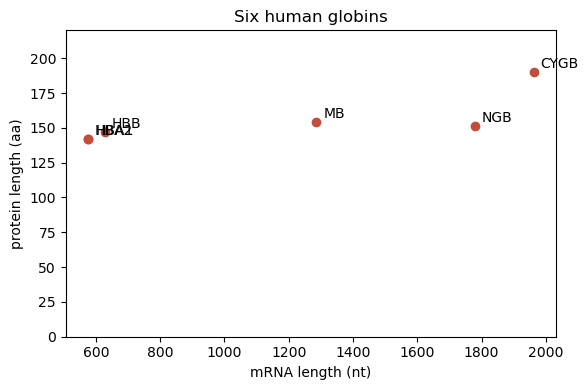

Pearson r = 0.78, p = 0.07 (n = 6)
untranslated sequence: 147-1389 nt


In [21]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(globins["mrna_length"], globins["protein_length"], color="#c14e3a")
for _, row in globins.iterrows():
    ax.annotate(row["gene"], (row["mrna_length"], row["protein_length"]), xytext=(5, 3), textcoords="offset points")
ax.set_xlabel("mRNA length (nt)"); ax.set_ylabel("protein length (aa)")
ax.set_ylim(0, 220); ax.set_title("Six human globins")
plt.tight_layout(); plt.show()

r, p = stats.pearsonr(globins["mrna_length"], globins["protein_length"])
print(f"Pearson r = {r:.2f}, p = {p:.2f} (n = {len(globins)})")
print(f"untranslated sequence: {globins['untranslated'].min()}-{globins['untranslated'].max()} nt")

**What we found.** The proteins are all about the same size (142-190
amino acids, one globin fold each), but the mRNAs differ more than
threefold; the difference is almost all untranslated sequence (UTRs). A
transcript's length says little about its protein. With only six genes,
a correlation of $r = 0.78$ has $p = 0.07$: a strong-looking correlation
from few points is weak evidence.

The lab continues from here.